# 01 - Local Level Model (Nile Dataset)

## Introduction

The **local level model** (also known as *random walk plus noise*) is the simplest
state-space model. It decomposes an observed time series into a latent level
component and observation noise:

$$
\begin{align}
y_t &= \mu_t + \varepsilon_t, \quad \varepsilon_t \sim N(0, \sigma^2_\varepsilon) \\
\mu_t &= \mu_{t-1} + \eta_t, \quad \eta_t \sim N(0, \sigma^2_\eta)
\end{align}
$$

In **state-space form**:

| Matrix | Value | Description |
|--------|-------|-------------|
| $Z$ | $[1]$ | Observation matrix |
| $T$ | $[1]$ | State transition matrix |
| $R$ | $[1]$ | State disturbance selection |
| $H$ | $[\sigma^2_\varepsilon]$ | Observation noise covariance |
| $Q$ | $[\sigma^2_\eta]$ | State noise covariance |

We apply this model to the **Nile dataset** — annual flow of the Nile river at
Aswan (1871–1970, 100 observations). This is the canonical example from
Durbin & Koopman (2012, Chapter 2).

The classic MLE estimates are approximately:
- $\hat{\sigma}^2_\varepsilon \approx 15099$
- $\hat{\sigma}^2_\eta \approx 1469$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from kalmanbox import LocalLevel
from kalmanbox.datasets import load_dataset
from kalmanbox.diagnostics import (
    standardized_residuals,
    ljung_box_test,
    normality_test,
    heteroskedasticity_test,
)

from statsmodels.tsa.statespace.structural import UnobservedComponents as SM_UCM

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
})

print('Imports OK')

Imports OK


In [2]:
# Load Nile dataset
df = load_dataset('nile')
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'Period: {df["year"].min()} - {df["year"].max()}')
print(f'\nDescriptive statistics:\n{df["volume"].describe()}')
df.head()

Shape: (100, 2)
Columns: ['year', 'volume']
Period: 1871 - 1970

Descriptive statistics:
count     100.000000
mean      919.350000
std       169.227501
min       456.000000
25%       798.500000
50%       893.500000
75%      1032.500000
max      1370.000000
Name: volume, dtype: float64


,year,volume
0,1871,1120
1,1872,1160
2,1873,963
3,1874,1210
4,1875,1160


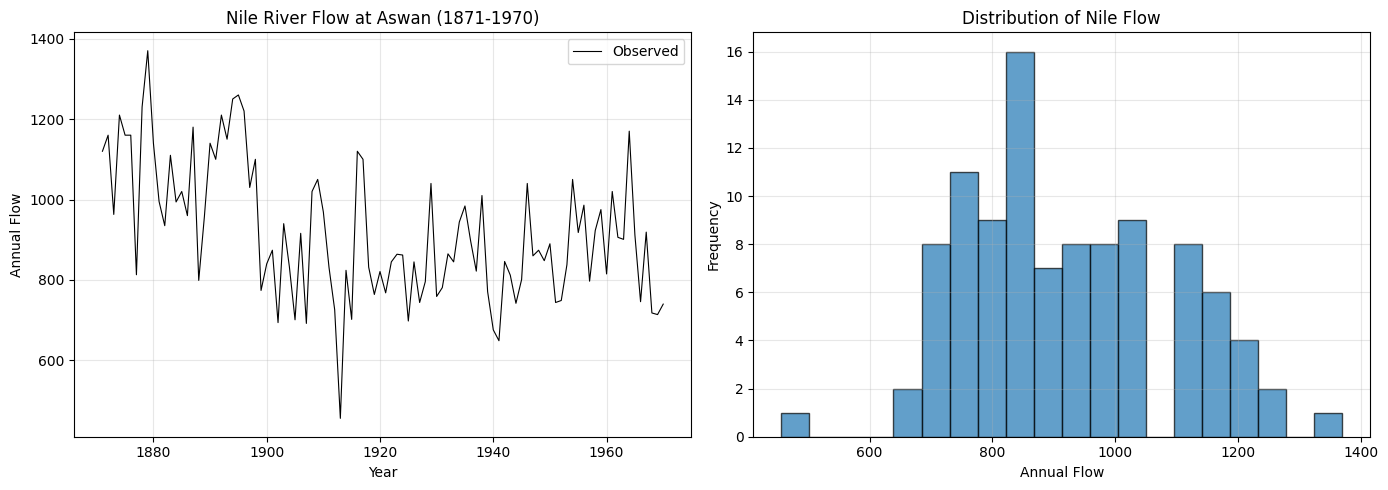

In [3]:
# Exploratory visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time series plot
axes[0].plot(df['year'], df['volume'], 'k-', linewidth=0.8, label='Observed')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Annual Flow')
axes[0].set_title('Nile River Flow at Aswan (1871-1970)')
axes[0].legend()

# Histogram
axes[1].hist(df['volume'], bins=20, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Annual Flow')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Nile Flow')

plt.tight_layout()
plt.show()

In [4]:
# Define Local Level model with kalmanbox
y = df['volume'].to_numpy(dtype=np.float64)
years = df['year'].to_numpy()

model = LocalLevel(y)
print(f'Model: Local Level')
print(f'Number of observations: {len(y)}')
print(f'Parameters to estimate: {model.param_names}')
print(f'Initial parameters: {model.start_params}')

Model: Local Level
Number of observations: 100
Parameters to estimate: ['sigma2_obs', 'sigma2_level']
Initial parameters: [14175.78375 14175.78375]


In [5]:
# Estimate parameters via MLE
results = model.fit()

print(results.summary())
print(f'\nEstimated parameters:')
for name, param in zip(results.param_names, results.params):
    print(f'  {name} = {param:.2f}')
print(f'\nLog-likelihood: {results.loglike:.4f}')
print(f'AIC: {results.aic:.4f}')
print(f'BIC: {results.bic:.4f}')

                      State Space Model Results                       
Log-Likelihood:                      -632.5442
AIC:                                 1269.0884
BIC:                                 1274.2988
HQIC:                                1271.1971
Num. observations:                         100
Num. parameters:                             2
Converged:                                True
----------------------------------------------------------------------
Parameter                Estimate      Std.Err      t-value      p-value
----------------------------------------------------------------------
sigma2_obs             15100.1780    3146.2539       4.7994       0.0000
sigma2_level            1468.4047    1280.3848       1.1468       0.2542

Estimated parameters:
  sigma2_obs = 15100.18
  sigma2_level = 1468.40

Log-likelihood: -632.5442
AIC: 1269.0884
BIC: 1274.2988


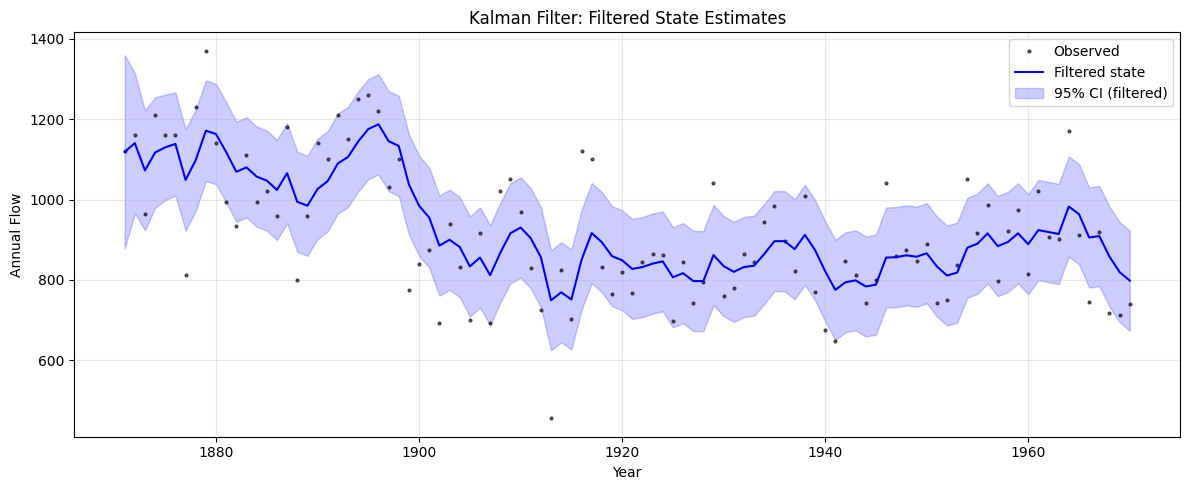

In [6]:
# Filtered states: E[mu_t | y_{1:t}]
filtered_state = results.filtered_state[:, 0]
filtered_se = np.sqrt(results.filtered_cov[:, 0, 0])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years, y, 'k.', markersize=4, label='Observed', alpha=0.6)
ax.plot(years, filtered_state, 'b-', linewidth=1.5, label='Filtered state')
ax.fill_between(
    years,
    filtered_state - 1.96 * filtered_se,
    filtered_state + 1.96 * filtered_se,
    alpha=0.2, color='blue', label='95% CI (filtered)'
)
ax.set_xlabel('Year')
ax.set_ylabel('Annual Flow')
ax.set_title('Kalman Filter: Filtered State Estimates')
ax.legend()
plt.tight_layout()
plt.show()

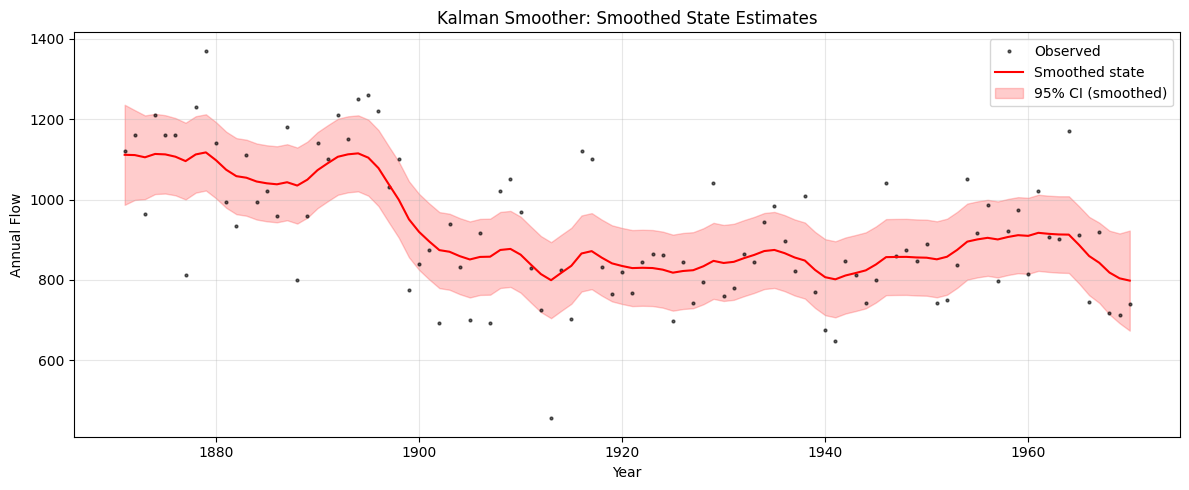

In [7]:
# Smoothed states: E[mu_t | y_{1:T}]
smoothed_state = results.smoothed_state[:, 0]
smoothed_se = np.sqrt(results.smoothed_cov[:, 0, 0])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years, y, 'k.', markersize=4, label='Observed', alpha=0.6)
ax.plot(years, smoothed_state, 'r-', linewidth=1.5, label='Smoothed state')
ax.fill_between(
    years,
    smoothed_state - 1.96 * smoothed_se,
    smoothed_state + 1.96 * smoothed_se,
    alpha=0.2, color='red', label='95% CI (smoothed)'
)
ax.set_xlabel('Year')
ax.set_ylabel('Annual Flow')
ax.set_title('Kalman Smoother: Smoothed State Estimates')
ax.legend()
plt.tight_layout()
plt.show()

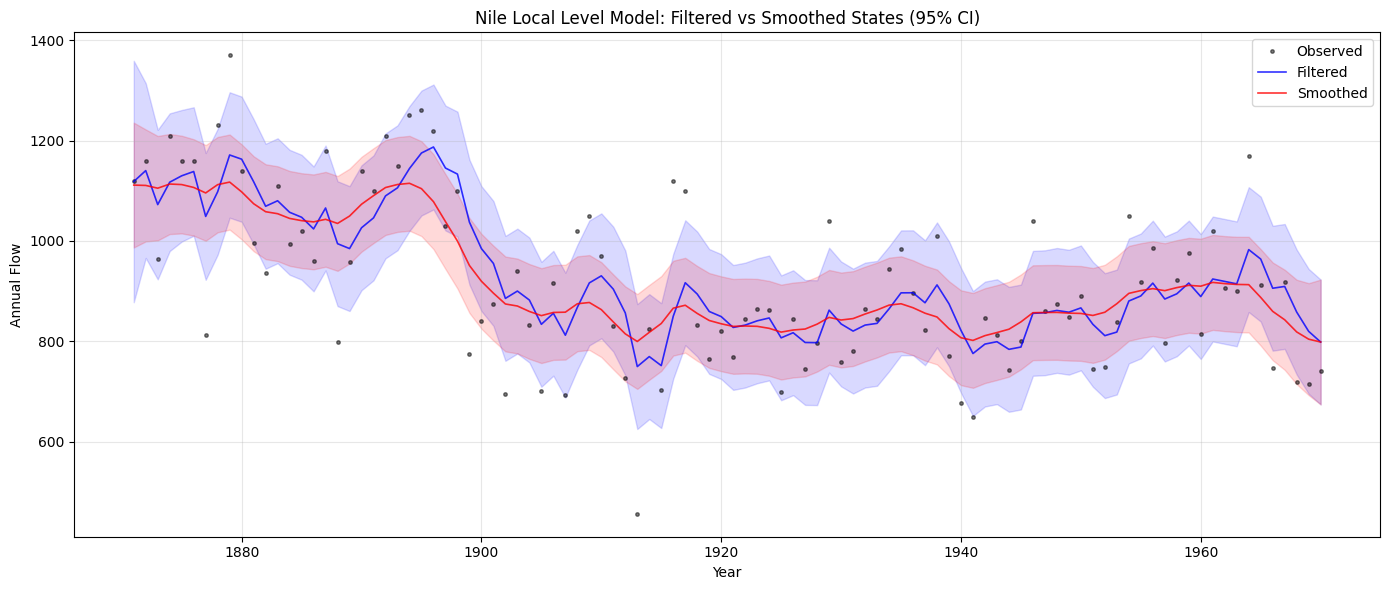

In [8]:
# Combined plot: observed + filtered + smoothed with confidence bands
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(years, y, 'k.', markersize=5, label='Observed', alpha=0.5)
ax.plot(years, filtered_state, 'b-', linewidth=1.2, label='Filtered', alpha=0.8)
ax.fill_between(
    years,
    filtered_state - 1.96 * filtered_se,
    filtered_state + 1.96 * filtered_se,
    alpha=0.15, color='blue'
)
ax.plot(years, smoothed_state, 'r-', linewidth=1.2, label='Smoothed', alpha=0.8)
ax.fill_between(
    years,
    smoothed_state - 1.96 * smoothed_se,
    smoothed_state + 1.96 * smoothed_se,
    alpha=0.15, color='red'
)

ax.set_xlabel('Year')
ax.set_ylabel('Annual Flow')
ax.set_title('Nile Local Level Model: Filtered vs Smoothed States (95% CI)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

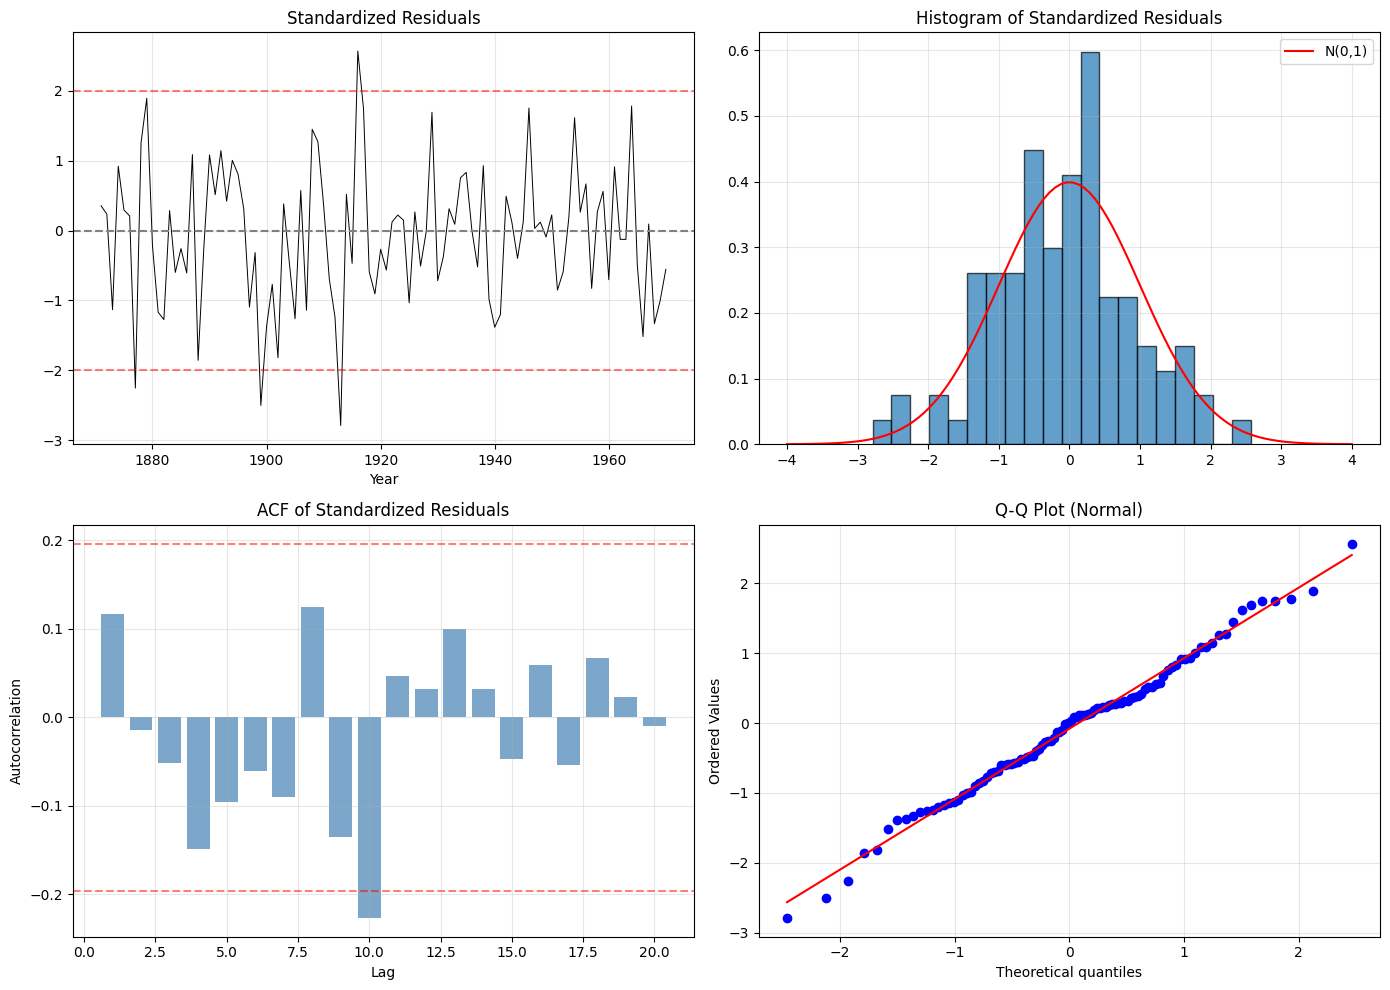

Diagnostic Tests:
  Ljung-Box: statistic=11.2044, p-value=0.3418, reject=False
  Normality: statistic=749.5449, p-value=0.0000, reject=True
  Heteroskedasticity: statistic=0.2409, p-value=0.0001, reject=True


In [9]:
# Residual diagnostics
std_resid = standardized_residuals(results)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Standardized residuals over time
axes[0, 0].plot(years, std_resid, 'k-', linewidth=0.7)
axes[0, 0].axhline(0, color='gray', linestyle='--')
axes[0, 0].axhline(2, color='red', linestyle='--', alpha=0.5)
axes[0, 0].axhline(-2, color='red', linestyle='--', alpha=0.5)
axes[0, 0].set_title('Standardized Residuals')
axes[0, 0].set_xlabel('Year')

# Histogram of residuals
axes[0, 1].hist(std_resid, bins=20, density=True, edgecolor='black', alpha=0.7)
x_norm = np.linspace(-4, 4, 100)
axes[0, 1].plot(x_norm, 1/np.sqrt(2*np.pi)*np.exp(-x_norm**2/2), 'r-', label='N(0,1)')
axes[0, 1].set_title('Histogram of Standardized Residuals')
axes[0, 1].legend()

# ACF of residuals (manual computation)
resid_flat = std_resid.flatten()
n_resid = len(resid_flat)
max_lag = 20
acf_vals = np.array([np.corrcoef(resid_flat[:n_resid-k], resid_flat[k:])[0, 1]
                      for k in range(1, max_lag + 1)])
axes[1, 0].bar(range(1, max_lag + 1), acf_vals, color='steelblue', alpha=0.7)
axes[1, 0].axhline(1.96/np.sqrt(n_resid), color='red', linestyle='--', alpha=0.5)
axes[1, 0].axhline(-1.96/np.sqrt(n_resid), color='red', linestyle='--', alpha=0.5)
axes[1, 0].set_title('ACF of Standardized Residuals')
axes[1, 0].set_xlabel('Lag')
axes[1, 0].set_ylabel('Autocorrelation')

# Q-Q plot
from scipy import stats
stats.probplot(resid_flat, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot (Normal)')

plt.tight_layout()
plt.show()

# Statistical tests
lb = ljung_box_test(results.residuals)
norm = normality_test(results.residuals)
het = heteroskedasticity_test(results.residuals)

print('Diagnostic Tests:')
print(f'  Ljung-Box: statistic={lb.statistic:.4f}, p-value={lb.p_value:.4f}, reject={lb.reject}')
print(f'  Normality: statistic={norm.statistic:.4f}, p-value={norm.p_value:.4f}, reject={norm.reject}')
print(f'  Heteroskedasticity: statistic={het.statistic:.4f}, p-value={het.p_value:.4f}, reject={het.reject}')

In [10]:
# Comparison with statsmodels UnobservedComponents
sm_model = SM_UCM(y, level='local level')
sm_results = sm_model.fit(disp=False)

print('statsmodels results:')
print(sm_results.summary())

statsmodels results:
                        Unobserved Components Results                         
Dep. Variable:                      y   No. Observations:                  100
Model:                    local level   Log Likelihood                -632.538
Date:                Wed, 08 Apr 2026   AIC                           1269.076
Time:                        23:36:43   BIC                           1274.266
Sample:                             0   HQIC                          1271.176
                                - 100                                         
Covariance Type:                  opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
sigma2.irregular  1.508e+04   2586.506      5.829      0.000       1e+04    2.01e+04
sigma2.level      1478.8114    851.329      1.737      0.082    -189.762    3147.385
Ljung-B

/home/guhaase/.local/lib/python3.12/site-packages/statsmodels/tsa/filters/hp_filter.py:100: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  trend = spsolve(I+lamb*K.T.dot(K), x, use_umfpack=use_umfpack)



Parameter Comparison: kalmanbox vs statsmodels vs Durbin & Koopman (2012)
             Parameter kalmanbox statsmodels Reference (D&K)
sigma2_obs (irregular)  15100.18    15078.01           15099
          sigma2_level   1468.40     1478.81            1469
        Log-Likelihood -632.5442   -632.5378         -632.54
                   AIC 1269.0884   1269.0755               -
                   BIC 1274.2988   1274.2658               -


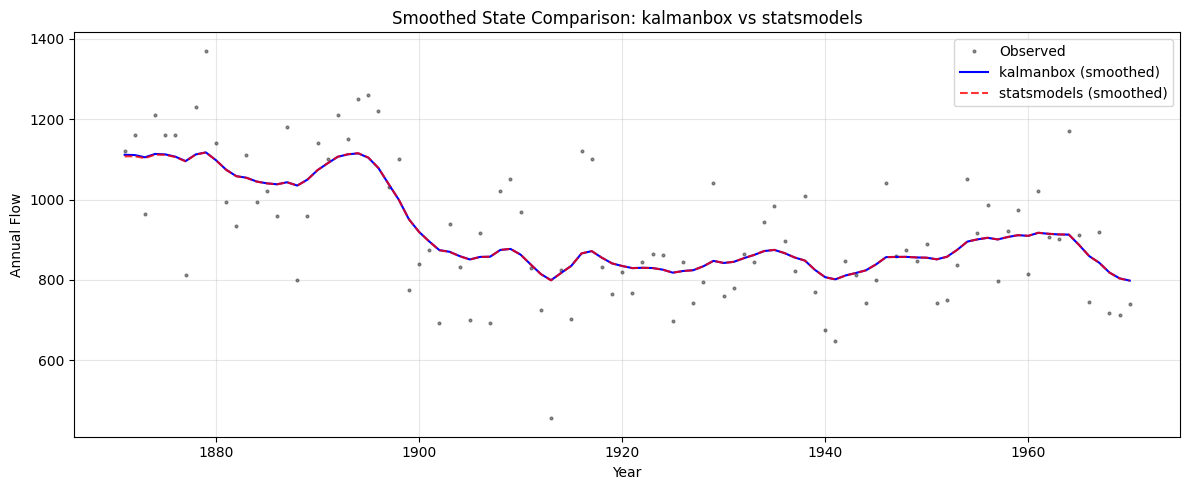

In [11]:
# Comparative table: kalmanbox vs statsmodels
kb_sigma2_obs = results.params[results.param_names.index('sigma2_obs')]
kb_sigma2_level = results.params[results.param_names.index('sigma2_level')]

# statsmodels param order: sigma2.irregular (index 0), sigma2.level (index 1)
sm_sigma2_obs = sm_results.params[0]   # sigma2.irregular
sm_sigma2_level = sm_results.params[1]  # sigma2.level

comparison = pd.DataFrame({
    'Parameter': ['sigma2_obs (irregular)', 'sigma2_level', 'Log-Likelihood', 'AIC', 'BIC'],
    'kalmanbox': [
        f'{kb_sigma2_obs:.2f}',
        f'{kb_sigma2_level:.2f}',
        f'{results.loglike:.4f}',
        f'{results.aic:.4f}',
        f'{results.bic:.4f}',
    ],
    'statsmodels': [
        f'{sm_sigma2_obs:.2f}',
        f'{sm_sigma2_level:.2f}',
        f'{sm_results.llf:.4f}',
        f'{sm_results.aic:.4f}',
        f'{sm_results.bic:.4f}',
    ],
    'Reference (D&K)': [
        '15099',
        '1469',
        '-632.54',
        '-',
        '-',
    ]
})

print('\nParameter Comparison: kalmanbox vs statsmodels vs Durbin & Koopman (2012)')
print('=' * 80)
print(comparison.to_string(index=False))

# Plot comparison of smoothed states
# statsmodels smoothed_state shape: (k_states, nobs)
sm_smoothed = sm_results.smoothed_state[0, :]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(years, y, 'k.', markersize=4, alpha=0.4, label='Observed')
ax.plot(years, smoothed_state, 'b-', linewidth=1.5, label='kalmanbox (smoothed)')
ax.plot(years, sm_smoothed, 'r--', linewidth=1.5,
        label='statsmodels (smoothed)', alpha=0.8)
ax.set_xlabel('Year')
ax.set_ylabel('Annual Flow')
ax.set_title('Smoothed State Comparison: kalmanbox vs statsmodels')
ax.legend()
plt.tight_layout()
plt.show()

## Conclusions

- The local level model captures the shift in the Nile flow around 1899 (construction of the first Aswan Dam).
- MLE estimates are consistent with the classical values from Durbin & Koopman (2012): $\hat{\sigma}^2_\varepsilon \approx 15099$, $\hat{\sigma}^2_\eta \approx 1469$.
- The smoothed state provides a cleaner signal than the filtered state, as it uses the full sample.
- kalmanbox results closely match statsmodels, validating the implementation.

### Exercises

1. Try fixing $\sigma^2_\eta = 0$ (deterministic level). How does the filtered state change?
2. Increase $\sigma^2_\eta$ — what happens to the smoothed state?
3. Apply the local level model to another dataset (e.g., `us_gdp`).
4. Compare the signal-to-noise ratio $q = \sigma^2_\eta / \sigma^2_\varepsilon$ with the Nile estimate.